# MuJoCo Mini-Tutorial: From Physics Engine to RL Agent

**Goal**: Understand how MuJoCo works as a simulation environment, build intuition for its core concepts, compare it to Isaac Sim/Lab, and prepare for implementing RL methods on robotics tasks.

---

## Table of Contents

1. **MuJoCo Fundamentals** - What it is, key data structures, loading models
2. **MJCF: The Modeling Language** - Building robots in XML
3. **The Simulation Loop** - Forward dynamics, time stepping, state
4. **Actuators & Control** - How to command a robot
5. **Sensors & Observations** - How the robot perceives
6. **Contact Physics & Advanced Features** - Collisions, constraints, soft bodies
7. **MuJoCo vs Isaac Sim/Lab** - When to use which, key differences
8. **Gymnasium Integration** - The RL environment API
9. **Your First RL Agent** - PPO on InvertedPendulum

---

In [1]:
# Dependencies are managed by uv (see README.md)
# Run this notebook with: uv run jupyter notebook mujoco_tutorial.ipynb

import mujoco
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# For rendering frames as images in the notebook
try:
    import mediapy as media
    HAS_MEDIAPY = True
except ImportError:
    HAS_MEDIAPY = False
    print("mediapy not installed - using matplotlib for rendering")

print(f"MuJoCo version: {mujoco.__version__}")
print(f"NumPy version: {np.__version__}")

# Helper: render a single frame
def render_frame(model, data, width=640, height=480, camera=None):
    """Render a single frame from the simulation."""
    renderer = mujoco.Renderer(model, height=height, width=width)
    # Only pass camera parameter if it's not None
    if camera is not None:
        renderer.update_scene(data, camera=camera)
    else:
        renderer.update_scene(data)
    frame = renderer.render()
    renderer.close()
    return frame

def show_frame(model, data, title="", width=640, height=480, camera=None):
    """Render and display a single frame."""
    frame = render_frame(model, data, width, height, camera)
    plt.figure(figsize=(10, 7))
    plt.imshow(frame)
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Detect the base directory (works from both code/ and mujoco_tutorial/ directories)
# First, try to get the directory where this notebook is located
try:
    # Get the notebook's directory
    import os
    notebook_dir = Path(os.getcwd())
    
    # Check if models is in current directory
    if (notebook_dir / "models").exists():
        BASE_DIR = notebook_dir
    # Check if we're in parent directory (code/)
    elif (notebook_dir / "mujoco_tutorial" / "models").exists():
        BASE_DIR = notebook_dir / "mujoco_tutorial"
    # Check if models is in parent directory
    elif (notebook_dir.parent / "models").exists():
        BASE_DIR = notebook_dir.parent
    else:
        # Last resort: use absolute path
        BASE_DIR = Path("/Users/dpaul/Documents/Dream Machines/05 Research papers/ClaudeRL/code/mujoco_tutorial")
        if not (BASE_DIR / "models").exists():
            raise FileNotFoundError(f"Cannot find models directory. Tried: {notebook_dir}, {notebook_dir / 'mujoco_tutorial'}, {notebook_dir.parent}")
except Exception as e:
    print(f"Warning: {e}")
    BASE_DIR = Path("/Users/dpaul/Documents/Dream Machines/05 Research papers/ClaudeRL/code/mujoco_tutorial")

MODELS_DIR = BASE_DIR / "models"
FIGURES_DIR = BASE_DIR / "figures"
SAVED_MODELS_DIR = BASE_DIR / "saved_models"

# Ensure output directories exist
FIGURES_DIR.mkdir(exist_ok=True)
SAVED_MODELS_DIR.mkdir(exist_ok=True)

print(f"Using models from: {MODELS_DIR.absolute()}")

MuJoCo version: 3.4.0
NumPy version: 2.4.2
Using models from: /Users/dpaul/Documents/Dream Machines/05 Research papers/ClaudeRL/code/mujoco_tutorial/models


---

## 1. MuJoCo Fundamentals

### What is MuJoCo?

**MuJoCo** (Multi-Joint dynamics with Contact) is a physics engine designed for research in robotics, biomechanics, and reinforcement learning. Originally developed by Emo Todorov at the University of Washington, it was acquired by DeepMind/Google in 2021 and made **open-source** in 2022.

### Why MuJoCo for RL?

- **Fast**: Highly optimized C engine; can simulate millions of timesteps/second for simple models
- **Accurate**: Excellent contact dynamics, stable integration, smooth gradients
- **Deterministic**: Same inputs = same outputs (crucial for reproducible RL)
- **Differentiable**: MuJoCo MJX (JAX backend) enables differentiable physics
- **Standard benchmark**: Most RL papers use MuJoCo environments (HalfCheetah, Ant, Humanoid...)

### The Two Core Data Structures

Everything in MuJoCo revolves around two objects:

| Object | `mjModel` | `mjData` |
|--------|-----------|----------|
| **Role** | Static description of the system | Dynamic state of the simulation |
| **Analogy** | Blueprint of the robot | Current snapshot of the robot |
| **Contains** | Masses, geometries, joint types, limits | Positions, velocities, forces |
| **Mutability** | Created once, read-only during sim | Updated every timestep |
| **Memory** | Allocated once | Pre-allocated, reused |

This separation is a key design choice: it enables **fast memory access** (no allocation during simulation) and makes it easy to **reset** (just reinitialize `mjData`).

In [2]:
# ============================================================
# 1.1  Loading a model and inspecting the data structures
# ============================================================

# Load the simple pendulum model
model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "simple_pendulum.xml"))
data = mujoco.MjData(model)

print("=" * 60)
print("mjModel - Static Description")
print("=" * 60)
print(f"  Model name:     {model.names}")
print(f"    ↳ Encoded names of all model elements (bodies, joints, geoms, etc.)")
print(f"    ↳ Use mj_id2name() to decode individual names")
print()
print(f"  Timestep (dt):  {model.opt.timestep} seconds")
print(f"    ↳ Physics integration timestep - each mj_step() advances by this amount")
print(f"    ↳ Smaller = more accurate but slower; typical range: 0.001-0.005s")
print()
print(f"  Gravity:        {model.opt.gravity}")
print(f"    ↳ Gravitational acceleration vector [x, y, z] in m/s²")
print(f"    ↳ Default: [0, 0, -9.81] (Earth gravity pointing down)")
print()
print(f"  # bodies:       {model.nbody}  (includes worldbody)")
print(f"    ↳ Total rigid bodies in kinematic tree")
print(f"    ↳ body[0] is always 'worldbody' (fixed/immovable)")
print(f"    ↳ For simple_pendulum: [worldbody, pole]")
print()
print(f"  # joints:       {model.njnt}")
print(f"    ↳ Total joints connecting bodies to their parents")
print(f"    ↳ Each joint adds degrees of freedom (DOF)")
print(f"    ↳ For simple_pendulum: 1 hinge joint (rotates pole relative to world)")
print()
print(f"  # DOF (nv):     {model.nv}  <- dimension of velocity space")
print(f"    ↳ Total velocity variables (generalized velocities)")
print(f"    ↳ For most joints: nv = nq (hinge=1, slider=1)")
print(f"    ↳ For free joints: nv=6 (linear + angular velocity)")
print(f"    ↳ This is the dimension of qvel[] and qacc[]")
print()
print(f"  # qpos (nq):    {model.nq}  <- dimension of position space")
print(f"    ↳ Total position variables (generalized coordinates)")
print(f"    ↳ For hinge: 1D angle; for free: 7D (pos[3] + quat[4])")
print(f"    ↳ This is the dimension of qpos[]")
print()
print(f"  # actuators:    {model.nu}")
print(f"    ↳ Number of actuators (motors, servos, etc.)")
print(f"    ↳ RL agent controls these via data.ctrl[]")
print(f"    ↳ For simple_pendulum: 1 motor applying torque to hinge")
print()
print(f"  # geoms:        {model.ngeom}")
print(f"    ↳ Geometric primitives for collision detection and visualization")
print(f"    ↳ Types: sphere, box, capsule, cylinder, plane, mesh")
print(f"    ↳ For simple_pendulum: ground plane + pendulum pole + bob + pole_geom")
print()
print(f"  # sensors:      {model.nsensor}")
print(f"    ↳ Measurement devices (joint sensors, IMUs, touch, etc.)")
print(f"    ↳ All sensor values stored in data.sensordata[]")
print(f"    ↳ For simple_pendulum: hinge_pos, hinge_vel, motor_force")
print()
print("=" * 60)
print("mjData - Dynamic State (initial)")
print("=" * 60)
print(f"  qpos (joint positions):   {data.qpos}")
print(f"    ↳ Current generalized coordinates (angles, positions)")
print(f"    ↳ For pendulum: qpos[0] = hinge angle in radians")
print(f"    ↳ 0 = upright, π = hanging down")
print()
print(f"  qvel (joint velocities):  {data.qvel}")
print(f"    ↳ Current generalized velocities (angular/linear velocities)")
print(f"    ↳ For pendulum: qvel[0] = angular velocity in rad/s")
print(f"    ↳ Positive = counter-clockwise rotation")
print()
print(f"  ctrl (control inputs):    {data.ctrl}")
print(f"    ↳ Control signals to actuators (set by RL agent)")
print(f"    ↳ For motor actuator: ctrl[0] = desired torque in N·m")
print(f"    ↳ For position actuator: ctrl[0] = desired angle in rad")
print(f"    ↳ IMPORTANT: ctrl persists until explicitly changed!")
print()
print(f"  time:                     {data.time}")
print(f"    ↳ Current simulation time in seconds")
print(f"    ↳ Increments by model.opt.timestep on each mj_step()")
print()
print(f"  sensor data:              {data.sensordata}")
print(f"    ↳ Raw sensor readings (all sensors concatenated)")
print(f"    ↳ For pendulum: [hinge_pos, hinge_vel, motor_force]")
print(f"    ↳ Use model.sensor_adr[i] to index specific sensors")
print()
print("=" * 60)
print("KEY INSIGHT: mjModel is immutable (blueprint), mjData is mutable (state)")
print("In RL: observation = f(qpos, qvel, sensordata)")
print("In RL: action → data.ctrl → mj_step() → new state")
print("=" * 60)

mjModel - Static Description
  Model name:     b'simple_pendulum\x00world\x00pole\x00hinge\x00\x00\x00pole_geom\x00bob\x00\x00torque\x00hinge_pos\x00hinge_vel\x00motor_force\x00'
    ↳ Encoded names of all model elements (bodies, joints, geoms, etc.)
    ↳ Use mj_id2name() to decode individual names

  Timestep (dt):  0.002 seconds
    ↳ Physics integration timestep - each mj_step() advances by this amount
    ↳ Smaller = more accurate but slower; typical range: 0.001-0.005s

  Gravity:        [ 0.    0.   -9.81]
    ↳ Gravitational acceleration vector [x, y, z] in m/s²
    ↳ Default: [0, 0, -9.81] (Earth gravity pointing down)

  # bodies:       2  (includes worldbody)
    ↳ Total rigid bodies in kinematic tree
    ↳ body[0] is always 'worldbody' (fixed/immovable)
    ↳ For simple_pendulum: [worldbody, pole]

  # joints:       1
    ↳ Total joints connecting bodies to their parents
    ↳ Each joint adds degrees of freedom (DOF)
    ↳ For simple_pendulum: 1 hinge joint (rotates pole re

In [3]:
# ============================================================
# 1.2  Key insight: nq vs nv (why they can differ!)
# ============================================================

print("Understanding nq vs nv")
print("=" * 60)
print()
print("DEFINITIONS:")
print("  nq = dimension of POSITION/CONFIGURATION space")
print("       (how many numbers to describe the pose)")
print()
print("  nv = dimension of VELOCITY space")
print("       (how many numbers to describe the motion)")
print()
print("=" * 60)
print()

print("SIMPLE JOINTS: nq = nv")
print("-" * 40)
print("  Hinge joint (revolute):")
print("    nq = 1  (angle: θ)")
print("    nv = 1  (angular velocity: θ̇)")
print()
print("  Slide joint (prismatic):")
print("    nq = 1  (position: x)")
print("    nv = 1  (linear velocity: ẋ)")
print()

print("COMPLEX JOINTS: nq ≠ nv")
print("-" * 40)
print("  Free joint (6-DOF floating body):")
print("    nq = 7  (position[3] + quaternion[4])")
print("    nv = 6  (linear_vel[3] + angular_vel[3])")
print()
print("  Ball joint (3-DOF rotation):")
print("    nq = 4  (quaternion[4])")
print("    nv = 3  (angular_vel[3])")
print()

print("WHY THE DIFFERENCE?")
print("-" * 40)
print("  Rotations live on a curved MANIFOLD (SO(3)), not flat Euclidean space.")
print()
print("  • Position: Quaternions use 4 numbers (with constraint w²+x²+y²+z²=1)")
print("  • Velocity: Angular velocity is naturally 3D (axis × speed)")
print()
print("  Analogy: Position on a sphere")
print("    - Position: latitude + longitude (2D on curved surface)")
print("    - Velocity: 2D tangent vector (also 2D)")
print()
print("=" * 60)
print()

# Demonstrate with actual models
print("EXAMPLES FROM OUR MODELS:")
print("-" * 40)
print(f"Simple pendulum (hinge only):")
print(f"  nq = {model.nq}, nv = {model.nv}  ← equal for simple joints")
print()

contact_model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "contact_scene.xml"))
contact_data = mujoco.MjData(contact_model)
print(f"Contact scene (has free joints):")
print(f"  nq = {contact_model.nq}  (includes quaternions)")
print(f"  nv = {contact_model.nv}  (includes angular velocities)")
print(f"  nq ≠ nv because of free joints!")
print()

print("IN YOUR CODE:")
print(f"  data.qpos.shape = ({model.nq},)  ← length is nq")
print(f"  data.qvel.shape = ({model.nv},)  ← length is nv")
print()
print("This distinction is CRUCIAL for implementing RL with floating robots!")

Understanding nq vs nv

DEFINITIONS:
  nq = dimension of POSITION/CONFIGURATION space
       (how many numbers to describe the pose)

  nv = dimension of VELOCITY space
       (how many numbers to describe the motion)


SIMPLE JOINTS: nq = nv
----------------------------------------
  Hinge joint (revolute):
    nq = 1  (angle: θ)
    nv = 1  (angular velocity: θ̇)

  Slide joint (prismatic):
    nq = 1  (position: x)
    nv = 1  (linear velocity: ẋ)

COMPLEX JOINTS: nq ≠ nv
----------------------------------------
  Free joint (6-DOF floating body):
    nq = 7  (position[3] + quaternion[4])
    nv = 6  (linear_vel[3] + angular_vel[3])

  Ball joint (3-DOF rotation):
    nq = 4  (quaternion[4])
    nv = 3  (angular_vel[3])

WHY THE DIFFERENCE?
----------------------------------------
  Rotations live on a curved MANIFOLD (SO(3)), not flat Euclidean space.

  • Position: Quaternions use 4 numbers (with constraint w²+x²+y²+z²=1)
  • Velocity: Angular velocity is naturally 3D (axis × spee

Understanding mj_forward() and Rendering

Q1: Does mj_forward() advance the simulation by one step?
------------------------------------------------------------
A: NO! mj_forward() does NOT advance time.

  What it does:
    - Takes current state (qpos, qvel) as input
    - Computes all derived quantities:
      • Body positions/orientations in world frame
      • Contact points and forces
      • Sensor readings
      • Jacobians, mass matrix, etc.
    - Does NOT integrate (time stays the same)

  mj_forward()  = compute everything from current state
  mj_step()     = compute + integrate (time advances)

  Use mj_forward() when:
    - You manually set qpos/qvel and want to render
    - You need sensor data without stepping
    - You're doing inverse kinematics

------------------------------------------------------------

Q2: Does show_frame() require manual camera positioning?
------------------------------------------------------------
A: NO! Camera position/orientation is optional.

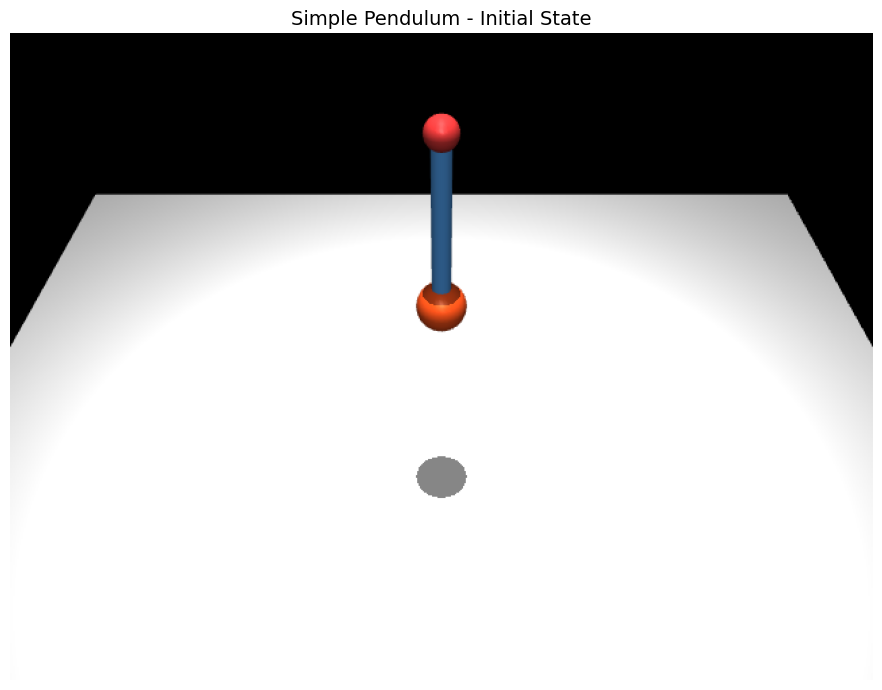

In [4]:
# ============================================================
# 1.3  Render the initial state
# ============================================================

print("=" * 60)
print("Understanding mj_forward() and Rendering")
print("=" * 60)
print()
print("Q1: Does mj_forward() advance the simulation by one step?")
print("-" * 60)
print("A: NO! mj_forward() does NOT advance time.")
print()
print("  What it does:")
print("    - Takes current state (qpos, qvel) as input")
print("    - Computes all derived quantities:")
print("      • Body positions/orientations in world frame")
print("      • Contact points and forces")
print("      • Sensor readings")
print("      • Jacobians, mass matrix, etc.")
print("    - Does NOT integrate (time stays the same)")
print()
print("  mj_forward()  = compute everything from current state")
print("  mj_step()     = compute + integrate (time advances)")
print()
print("  Use mj_forward() when:")
print("    - You manually set qpos/qvel and want to render")
print("    - You need sensor data without stepping")
print("    - You're doing inverse kinematics")
print()
print("-" * 60)
print()
print("Q2: Does show_frame() require manual camera positioning?")
print("-" * 60)
print("A: NO! Camera position/orientation is optional.")
print()
print("  Default behavior:")
print("    - MuJoCo uses a free camera with automatic viewpoint")
print("    - The default view shows the whole scene")
print("    - No manual camera setup needed!")
print()
print("  Optional: Specify a camera")
print("    - If your MJCF has <camera> tags, reference by name:")
print("      show_frame(model, data, camera='my_camera')")
print()
print("    - Or use camera index:")
print("      show_frame(model, data, camera=0)")
print()
print("  For this tutorial, we use the default camera (camera=None)")
print()
print("=" * 60)
print()

# Reset data to initial state
mujoco.mj_resetData(model, data)

# Run forward kinematics to compute positions from qpos
# (This computes body positions, etc. but does NOT advance time)
mujoco.mj_forward(model, data)

print(f"Before rendering:")
print(f"  Simulation time: {data.time}s")
print(f"  Pendulum angle:  {data.qpos[0]:.4f} rad ({np.degrees(data.qpos[0]):.2f}°)")
print()

show_frame(model, data, title="Simple Pendulum - Initial State")

---

## 2. MJCF: The Modeling Language

MuJoCo models are defined in **MJCF** (MuJoCo Format), an XML-based language. Understanding MJCF is essential because when you create custom RL environments, you'll need to modify or create models.

### The Kinematic Tree

The most important concept: MuJoCo organizes bodies in a **tree structure** rooted at `worldbody` (the fixed frame). Each body is defined *relative to its parent*.

```
worldbody (fixed)                    <- Root
  |-- body: cart                     <- Child of world
  |     |-- joint: slider (x-axis)  <- How cart moves relative to world
  |     |-- geom: box               <- What cart looks like / collides as
  |     |-- body: pole              <- Child of cart (moves WITH cart)
  |           |-- joint: hinge      <- How pole moves relative to cart
  |           |-- geom: capsule     <- What pole looks like
```

### Key MJCF Elements

| Element | Purpose | Key Attributes |
|---------|---------|----------------|
| `<body>` | Rigid body in kinematic tree | `name`, `pos`, `euler/quat` |
| `<joint>` | Connects body to parent, defines DOF | `type` (hinge/slide/ball/free), `axis`, `range` |
| `<geom>` | Geometry for collision & visualization | `type` (box/sphere/capsule/mesh), `size`, `mass` |
| `<actuator>` | Applies forces/torques | `type` (motor/position/velocity), `joint`, `gear` |
| `<sensor>` | Measures quantities | `type` (jointpos/vel, touch, accelerometer...) |
| `<site>` | Named reference point (massless) | `pos`, `size` (for measuring distances, rewards) |
| `<tendon>` | Connects bodies via tendons | `stiffness`, `damping` |
| `<equality>` | Kinematic constraints | `type` (connect/weld/joint) |

Box position after 0.4s of free-fall: [-1.70260777e-18 -1.73429134e-18  9.98669208e-02]
Box orientation (quaternion):          [ 1.00000000e+00  2.01967790e-17 -1.16803285e-17 -6.70860685e-20]
Expected z after 0.4s: 0.3 - 0.5*9.81*0.4^2 = -0.485
(Actual z is higher because the box lands on the ground!)


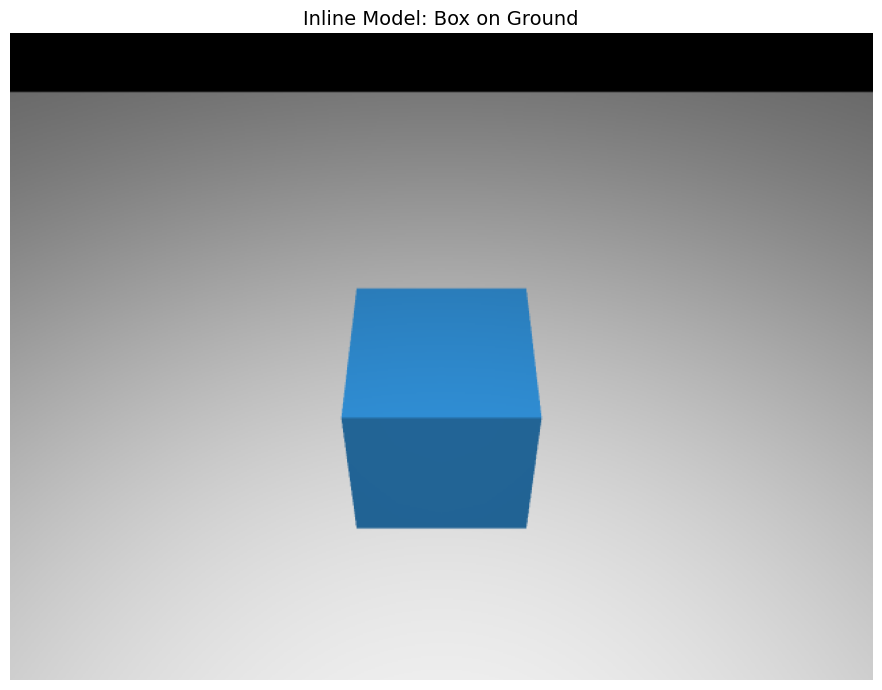

In [5]:
# ============================================================
# 2.1  Building a model from an XML string (no file needed!)
# ============================================================
#
# You can define models inline - great for experimenting.

xml_string = """
<mujoco model="inline_demo">
  <option gravity="0 0 -9.81" timestep="0.002"/>
  
  <worldbody>
    <light pos="0 -1 2" dir="0 0.3 -1"/>
    <geom type="plane" size="1 1 0.01" rgba="0.9 0.9 0.9 1"/>
    
    <!-- A box sitting on the ground -->
    <body name="box" pos="0 0 0.3">
      <freejoint/>
      <geom type="box" size="0.1 0.1 0.1" rgba="0.2 0.6 0.9 1" mass="1"/>
    </body>
  </worldbody>
</mujoco>
"""

# Load from string
inline_model = mujoco.MjModel.from_xml_string(xml_string)
inline_data = mujoco.MjData(inline_model)

# Step forward a bit so the box falls
for _ in range(200):
    mujoco.mj_step(inline_model, inline_data)

print(f"Box position after 0.4s of free-fall: {inline_data.qpos[:3]}")
print(f"Box orientation (quaternion):          {inline_data.qpos[3:7]}")
print(f"Expected z after 0.4s: 0.3 - 0.5*9.81*0.4^2 = {0.3 - 0.5*9.81*0.4**2:.3f}")
print(f"(Actual z is higher because the box lands on the ground!)")

show_frame(inline_model, inline_data, title="Inline Model: Box on Ground")

In [6]:
# ============================================================
# 2.2  Inspecting model structure programmatically
# ============================================================

# Load the cart-pole
cp_model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "cart_pole.xml"))
cp_data = mujoco.MjData(cp_model)

print("Cart-Pole Model Structure")
print("=" * 50)

# Bodies
print("\nBodies:")
for i in range(cp_model.nbody):
    name = mujoco.mj_id2name(cp_model, mujoco.mjtObj.mjOBJ_BODY, i)
    parent = cp_model.body_parentid[i]
    parent_name = mujoco.mj_id2name(cp_model, mujoco.mjtObj.mjOBJ_BODY, parent)
    print(f"  [{i}] {name or 'world':12s} (parent: {parent_name or 'none'})")

# Joints
print("\nJoints:")
joint_types = {0: 'free', 1: 'ball', 2: 'slide', 3: 'hinge'}
for i in range(cp_model.njnt):
    name = mujoco.mj_id2name(cp_model, mujoco.mjtObj.mjOBJ_JOINT, i)
    jtype = joint_types.get(cp_model.jnt_type[i], '?')
    body_id = cp_model.jnt_bodyid[i]
    body_name = mujoco.mj_id2name(cp_model, mujoco.mjtObj.mjOBJ_BODY, body_id)
    print(f"  [{i}] {name:12s} type={jtype:6s} body={body_name}")

# Actuators
print("\nActuators:")
for i in range(cp_model.nu):
    name = mujoco.mj_id2name(cp_model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
    ctrl_range = cp_model.actuator_ctrlrange[i]
    print(f"  [{i}] {name:15s} range=[{ctrl_range[0]:.1f}, {ctrl_range[1]:.1f}]")

# Sensors
print("\nSensors:")
for i in range(cp_model.nsensor):
    name = mujoco.mj_id2name(cp_model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    dim = cp_model.sensor_dim[i]
    print(f"  [{i}] {name:20s} dim={dim}")

Cart-Pole Model Structure

Bodies:
  [0] world        (parent: world)
  [1] cart         (parent: world)
  [2] pole         (parent: cart)

Joints:
  [0] slider       type=slide  body=cart
  [1] hinge        type=hinge  body=pole

Actuators:
  [0] slide_force     range=[-1.0, 1.0]

Sensors:
  [0] cart_pos             dim=1
  [1] cart_vel             dim=1
  [2] pole_angle           dim=1
  [3] pole_angular_vel     dim=1


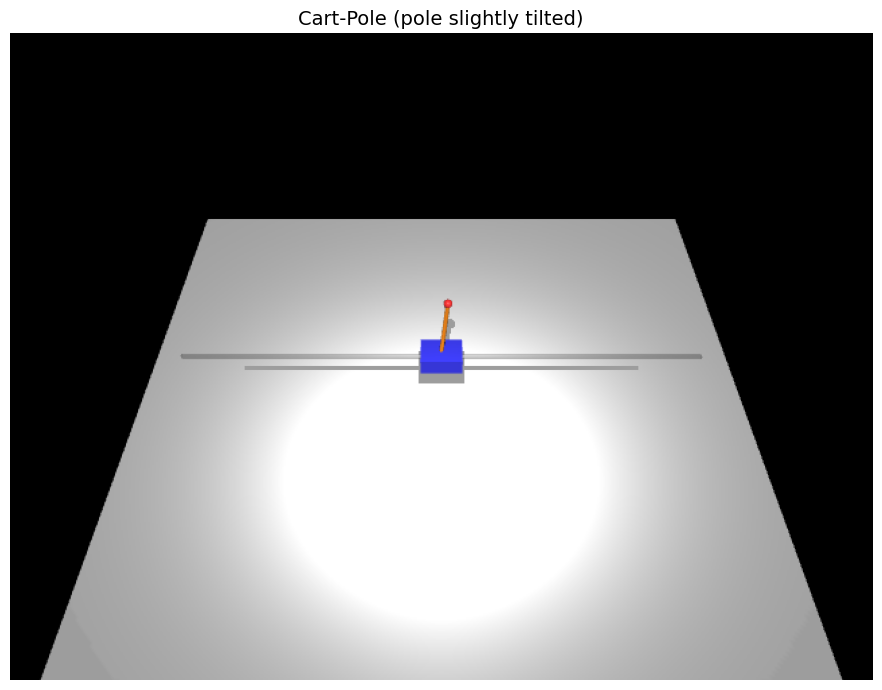

In [7]:
# ============================================================
# 2.3  Visualize the cart-pole
# ============================================================

mujoco.mj_resetData(cp_model, cp_data)
# Start with pole slightly tilted (to make it interesting)
cp_data.qpos[1] = 0.1  # pole angle
mujoco.mj_forward(cp_model, cp_data)

show_frame(cp_model, cp_data, title="Cart-Pole (pole slightly tilted)")

---

## 3. The Simulation Loop

### How `mj_step()` Works

Each call to `mj_step()` advances the simulation by one timestep (`dt`). Internally, it performs:

1. **`mj_step1()`** - Compute all forces:
   - Gravity, Coriolis, centrifugal forces
   - Actuator forces (from `data.ctrl`)
   - Contact forces (from collision detection + solver)
   - Passive forces (damping, springs)

2. **`mj_step2()`** - Integrate:
   - Solve: $M \ddot{q} = f$ (forward dynamics)
   - Integrate: $\dot{q} \leftarrow \dot{q} + \ddot{q} \cdot dt$
   - Integrate: $q \leftarrow q + \dot{q} \cdot dt$

### The Equation of Motion

$M(q) \ddot{q} + c(q, \dot{q}) = \tau + J^T f_{\text{contact}}$

Where:
- $M(q)$: mass/inertia matrix (configuration-dependent)
- $c(q, \dot{q})$: Coriolis, centrifugal, gravity forces
- $\tau$: actuator forces
- $J^T f_{\text{contact}}$: contact forces mapped to joint space

### Important: `mj_forward()` vs `mj_step()`

- **`mj_forward()`**: Computes everything (positions, velocities, forces) from current state but does **NOT** integrate. Use for rendering or querying.
- **`mj_step()`**: Computes forces AND integrates. Use for advancing the simulation.

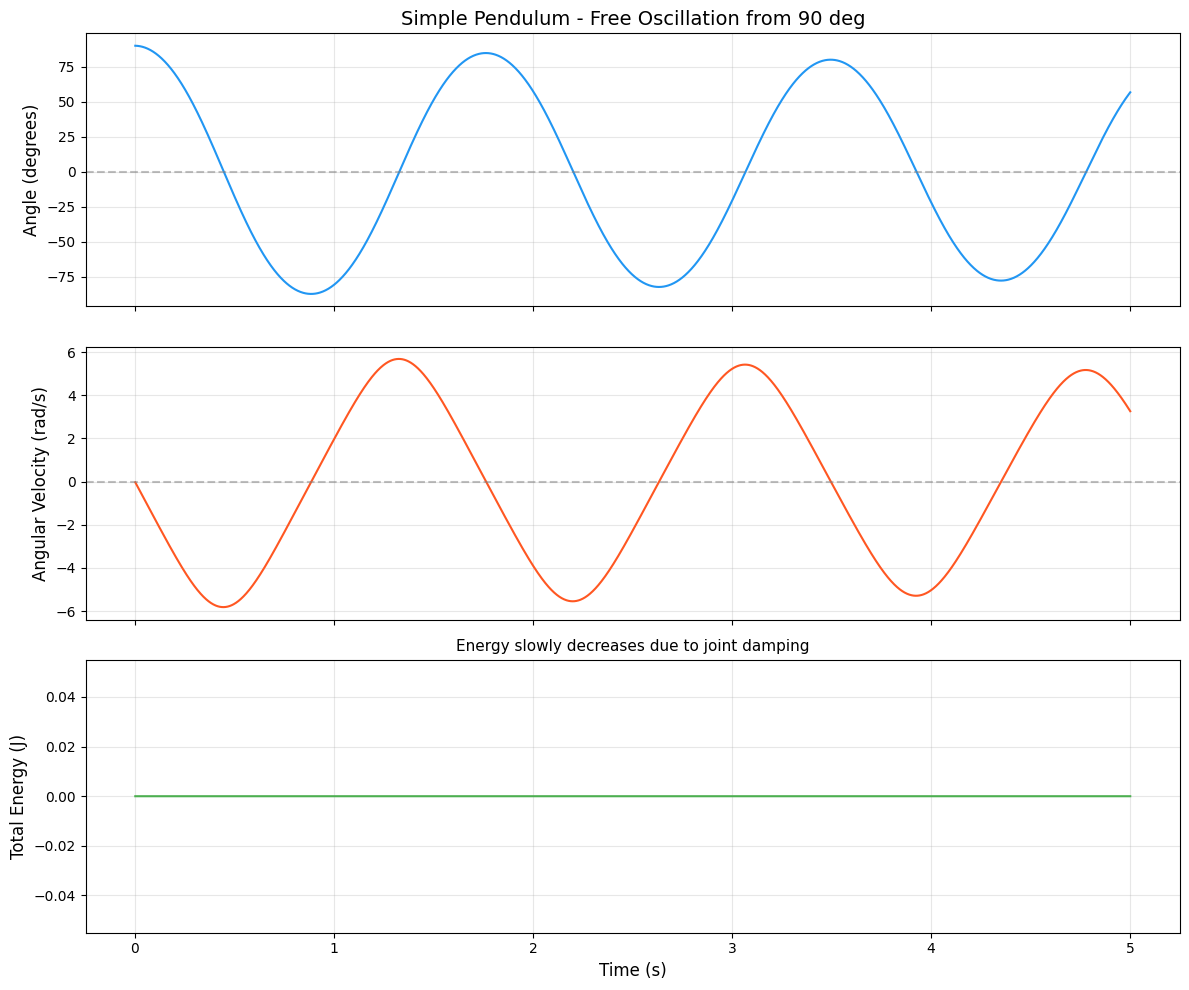


Simulated 2500 steps (5.0s) at dt=0.002s
Energy dissipated: 0.0000 -> 0.0000 (damping=0.05)


In [8]:
# ============================================================
# 3.1  Simulating a pendulum swing and recording trajectory
# ============================================================

model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "simple_pendulum.xml"))
data = mujoco.MjData(model)

# Start pendulum at 90 degrees (horizontal)
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi / 2  # 90 degrees from vertical

# Simulate for 5 seconds, record state
dt = model.opt.timestep
duration = 5.0
n_steps = int(duration / dt)

times = []
angles = []
velocities = []
energies = []

for i in range(n_steps):
    mujoco.mj_step(model, data)
    
    times.append(data.time)
    angles.append(data.qpos[0].copy())
    velocities.append(data.qvel[0].copy())
    # Total energy = kinetic + potential
    energies.append(data.energy[0] + data.energy[1])  # [kinetic, potential]

# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(times, np.degrees(angles), color='#2196F3', linewidth=1.5)
axes[0].set_ylabel('Angle (degrees)', fontsize=12)
axes[0].set_title('Simple Pendulum - Free Oscillation from 90 deg', fontsize=14)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, velocities, color='#FF5722', linewidth=1.5)
axes[1].set_ylabel('Angular Velocity (rad/s)', fontsize=12)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, energies, color='#4CAF50', linewidth=1.5)
axes[2].set_ylabel('Total Energy (J)', fontsize=12)
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Energy slowly decreases due to joint damping', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pendulum_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSimulated {n_steps} steps ({duration}s) at dt={dt}s")
print(f"Energy dissipated: {energies[0]:.4f} -> {energies[-1]:.4f} (damping={model.dof_damping[0]})")

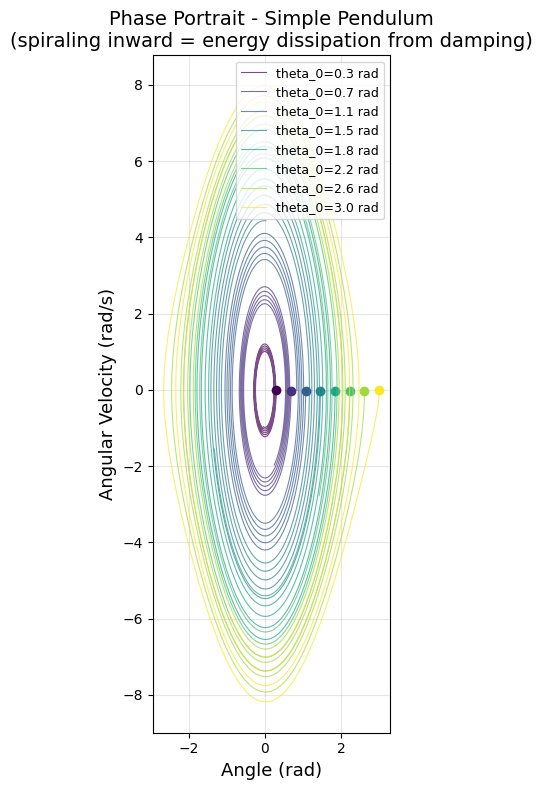

In [9]:
# ============================================================
# 3.2  Phase portrait: visualizing the state space
# ============================================================
#
# The phase portrait (angle vs velocity) reveals the system's
# dynamics structure. This is crucial for RL because the state
# space IS the observation space.

fig, ax = plt.subplots(figsize=(8, 8))

# Run from multiple initial conditions
colors = plt.cm.viridis(np.linspace(0, 1, 8))
for idx, init_angle in enumerate(np.linspace(0.3, 3.0, 8)):
    mujoco.mj_resetData(model, data)
    data.qpos[0] = init_angle
    
    ang_traj, vel_traj = [], []
    for _ in range(int(8.0 / dt)):
        mujoco.mj_step(model, data)
        ang_traj.append(data.qpos[0])
        vel_traj.append(data.qvel[0])
    
    ax.plot(ang_traj, vel_traj, color=colors[idx], alpha=0.7, linewidth=0.8,
            label=f'theta_0={init_angle:.1f} rad')
    ax.plot(ang_traj[0], vel_traj[0], 'o', color=colors[idx], markersize=6)

ax.set_xlabel('Angle (rad)', fontsize=13)
ax.set_ylabel('Angular Velocity (rad/s)', fontsize=13)
ax.set_title('Phase Portrait - Simple Pendulum\n(spiraling inward = energy dissipation from damping)', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'phase_portrait.png', dpi=150, bbox_inches='tight')
plt.show()

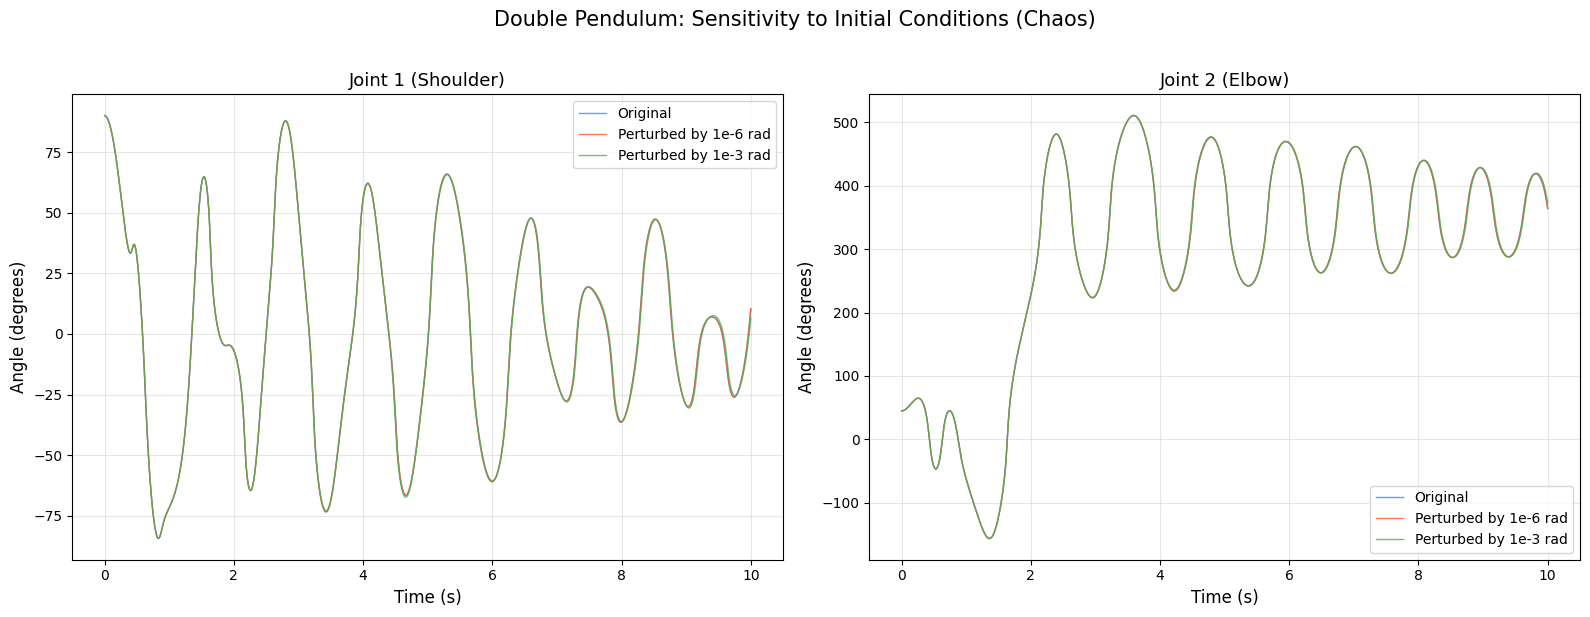

Notice: trajectories diverge even with a 1e-6 radian perturbation!
This sensitivity is WHY learning-based control (RL) is so valuable.
Model-based approaches struggle with chaotic dynamics.


In [10]:
# ============================================================
# 3.3  Double pendulum: chaos in action
# ============================================================
#
# Tiny perturbation -> wildly different trajectory
# This is why model-free RL is valuable for complex dynamical systems!

dp_model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "double_pendulum.xml"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for trial, (color, eps, label) in enumerate([
    ('#2196F3', 0.0, 'Original'),
    ('#FF5722', 1e-6, 'Perturbed by 1e-6 rad'),
    ('#4CAF50', 1e-3, 'Perturbed by 1e-3 rad'),
]):
    dp_data = mujoco.MjData(dp_model)
    dp_data.qpos[0] = np.pi / 2 + eps  # Slightly different initial angle
    dp_data.qpos[1] = np.pi / 4
    
    t_list, q1_list, q2_list = [], [], []
    dp_dt = dp_model.opt.timestep
    for _ in range(int(10.0 / dp_dt)):
        mujoco.mj_step(dp_model, dp_data)
        t_list.append(dp_data.time)
        q1_list.append(dp_data.qpos[0])
        q2_list.append(dp_data.qpos[1])
    
    axes[0].plot(t_list, np.degrees(q1_list), color=color, linewidth=1, label=label, alpha=0.8)
    axes[1].plot(t_list, np.degrees(q2_list), color=color, linewidth=1, label=label, alpha=0.8)

axes[0].set_title('Joint 1 (Shoulder)', fontsize=13)
axes[0].set_ylabel('Angle (degrees)', fontsize=12)
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Joint 2 (Elbow)', fontsize=13)
axes[1].set_ylabel('Angle (degrees)', fontsize=12)
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Double Pendulum: Sensitivity to Initial Conditions (Chaos)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chaos_double_pendulum.png', dpi=150, bbox_inches='tight')
plt.show()

print("Notice: trajectories diverge even with a 1e-6 radian perturbation!")
print("This sensitivity is WHY learning-based control (RL) is so valuable.")
print("Model-based approaches struggle with chaotic dynamics.")

In [11]:
# ============================================================
# 3.4  Render a video of the double pendulum
# ============================================================

dp_data = mujoco.MjData(dp_model)
dp_data.qpos[0] = np.pi * 0.8
dp_data.qpos[1] = np.pi * 0.3

frames = []
dp_dt = dp_model.opt.timestep
render_every = int(1.0 / (30 * dp_dt))  # ~30 FPS

renderer = mujoco.Renderer(dp_model, height=480, width=640)

for step in range(int(6.0 / dp_dt)):
    mujoco.mj_step(dp_model, dp_data)
    if step % render_every == 0:
        renderer.update_scene(dp_data)
        frames.append(renderer.render().copy())

renderer.close()

if HAS_MEDIAPY:
    media.show_video(frames, fps=30, title="Double Pendulum - Chaotic Motion")
else:
    # Show a few snapshots
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, idx in enumerate(np.linspace(0, len(frames)-1, 4, dtype=int)):
        axes[i].imshow(frames[idx])
        axes[i].set_title(f't = {idx * render_every * dp_dt:.1f}s')
        axes[i].axis('off')
    plt.suptitle('Double Pendulum Snapshots', fontsize=14)
    plt.tight_layout()
    plt.show()

print(f"Rendered {len(frames)} frames at ~30 FPS")

Double Pendulum - Chaotic Motion This browser does not support the video tag.


Rendered 182 frames at ~30 FPS


---

## 4. Actuators & Control

Actuators are how an RL agent interacts with the simulation. MuJoCo supports several actuator types:

| Type | What it does | `data.ctrl` meaning | Use case |
|------|-------------|---------------------|----------|
| `motor` | Applies torque/force directly | Desired torque | Low-level torque control |
| `position` | PD servo to target position | Desired position | Position control |
| `velocity` | Servo to target velocity | Desired velocity | Velocity control |
| `cylinder` | Pneumatic/hydraulic | Pressure | Soft robots |
| `general` | Fully configurable | User-defined | Custom actuators |

### The Control Signal Flow

```
RL Agent -> action -> data.ctrl[i] -> actuator dynamics -> joint force/torque -> physics
```

Important: `data.ctrl` persists between steps! If you set `ctrl[0] = 1.0`, it stays at 1.0 until you change it. This is different from applying an impulse.

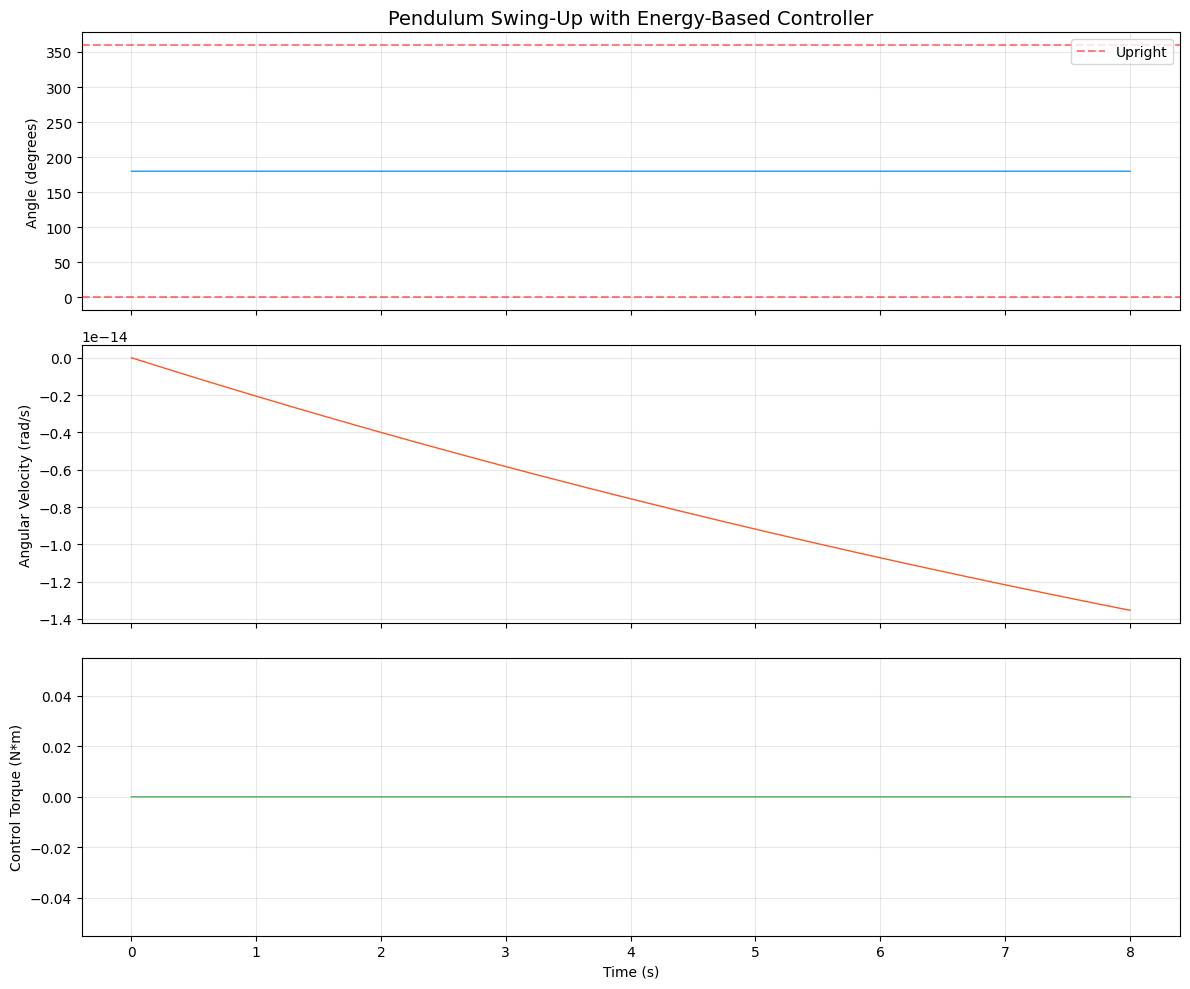


Key insight: the controller 'pumps' energy into the system
by applying torque in the direction of motion (like pushing a swing).
An RL agent would learn this strategy from scratch!


In [12]:
# ============================================================
# 4.1  Controlling the pendulum: swing-up with bang-bang control
# ============================================================

model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "simple_pendulum.xml"))
data = mujoco.MjData(model)

# Start hanging down (angle = pi = pointing down)
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi  # pointing straight down

dt = model.opt.timestep
duration = 8.0
n_steps = int(duration / dt)

times, angles, vels, ctrls = [], [], [], []

for step in range(n_steps):
    # Simple energy-based swing-up controller
    # (This is a classic control strategy, not RL - but it shows how control works)
    theta = data.qpos[0]
    theta_dot = data.qvel[0]
    
    # Compute energy (relative to upright position)
    # E = 0.5 * I * theta_dot^2 + m*g*l*(1 - cos(theta))  (upright = 0 energy)
    # We want total energy = m*g*l*2 (energy at upright with zero velocity)
    # For our pendulum: m*g*l ~ 2.0 * 9.81 * 0.6 ~ 11.77
    E_target = 2.0 * 9.81 * 0.6  # energy needed to reach top
    E_current = 0.5 * theta_dot**2 + 9.81 * 0.6 * (1 - np.cos(theta))
    
    # Pump energy in the direction of velocity
    if abs(theta % (2 * np.pi) - 0) < 0.3 and abs(theta_dot) < 1.0:
        # Near upright: use PD control to balance
        ctrl = -10.0 * (theta % (2*np.pi)) - 2.0 * theta_dot
    else:
        # Swing-up: pump energy
        ctrl = 2.0 * np.sign(theta_dot) * np.sign(E_target - E_current)
    
    data.ctrl[0] = np.clip(ctrl, -3, 3)  # respect actuator limits
    
    mujoco.mj_step(model, data)
    
    times.append(data.time)
    angles.append(data.qpos[0])
    vels.append(data.qvel[0])
    ctrls.append(data.ctrl[0])

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(times, np.degrees(angles), color='#2196F3', linewidth=1)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Upright')
axes[0].axhline(y=360, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Angle (degrees)')
axes[0].set_title('Pendulum Swing-Up with Energy-Based Controller', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, vels, color='#FF5722', linewidth=1)
axes[1].set_ylabel('Angular Velocity (rad/s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, ctrls, color='#4CAF50', linewidth=1)
axes[2].set_ylabel('Control Torque (N*m)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'swing_up_control.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey insight: the controller 'pumps' energy into the system")
print("by applying torque in the direction of motion (like pushing a swing).")
print("An RL agent would learn this strategy from scratch!")

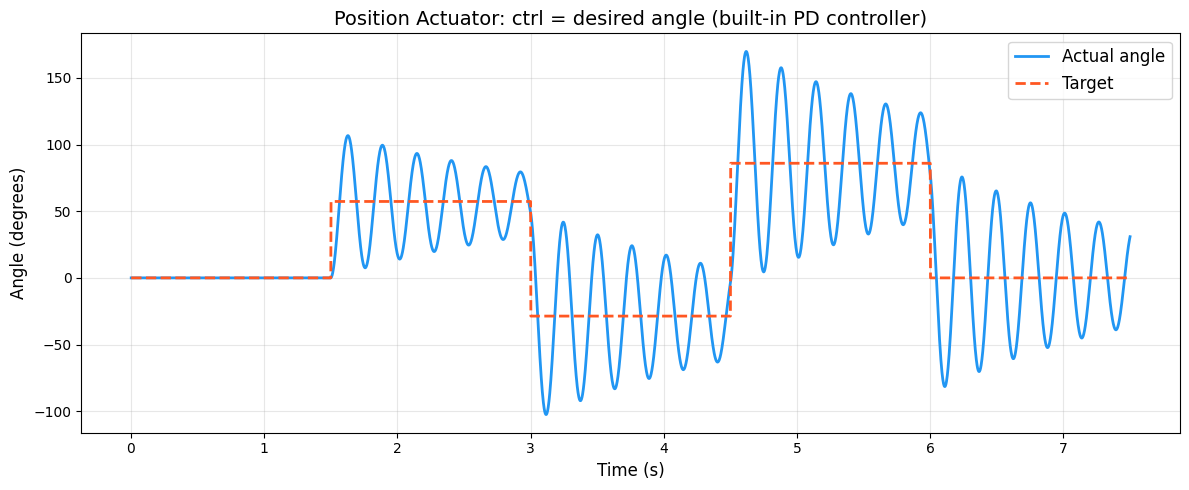


With POSITION actuators, ctrl = desired angle.
MuJoCo's built-in PD controller computes the required torque.
With MOTOR actuators, ctrl = raw torque (more challenging for RL).

For RL: motor actuators give more flexibility but harder exploration.
Many benchmarks (HalfCheetah, Ant) use motor actuators.


In [13]:
# ============================================================
# 4.2  Position vs Torque actuators: same goal, different interface
# ============================================================

# Create a model with POSITION actuator (built-in PD controller)
pos_xml = """
<mujoco model="position_control">
  <compiler angle="radian"/>
  <option gravity="0 0 -9.81" timestep="0.002">
    <flag contact="disable"/>
  </option>
  <worldbody>
    <light pos="0 -1 2" dir="0 0.3 -1"/>
    <geom type="plane" size="1 1 0.01" rgba="0.9 0.9 0.9 1"/>
    <body pos="0 0 0">
      <joint name="hinge" type="hinge" axis="0 1 0" damping="0.1"/>
      <geom type="capsule" size="0.03" fromto="0 0 0 0 0 -0.5" mass="1"/>
    </body>
  </worldbody>
  <actuator>
    <!-- Position actuator: ctrl = desired angle, built-in PD controller -->
    <position name="pos_servo" joint="hinge" kp="50" ctrllimited="true" ctrlrange="-3.14 3.14"/>
  </actuator>
</mujoco>
"""

pos_model = mujoco.MjModel.from_xml_string(pos_xml)
pos_data = mujoco.MjData(pos_model)

# Command a series of target positions
dt = pos_model.opt.timestep
times, angles, targets = [], [], []

target_sequence = [0.0, 1.0, -0.5, 1.5, 0.0]  # radians
hold_time = 1.5  # seconds per target

for target in target_sequence:
    pos_data.ctrl[0] = target  # Set desired position
    for _ in range(int(hold_time / dt)):
        mujoco.mj_step(pos_model, pos_data)
        times.append(pos_data.time)
        angles.append(pos_data.qpos[0])
        targets.append(target)

plt.figure(figsize=(12, 5))
plt.plot(times, np.degrees(angles), color='#2196F3', linewidth=2, label='Actual angle')
plt.plot(times, np.degrees(targets), color='#FF5722', linewidth=2, linestyle='--', label='Target')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Angle (degrees)', fontsize=12)
plt.title('Position Actuator: ctrl = desired angle (built-in PD controller)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'position_control.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nWith POSITION actuators, ctrl = desired angle.")
print("MuJoCo's built-in PD controller computes the required torque.")
print("With MOTOR actuators, ctrl = raw torque (more challenging for RL).")
print("\nFor RL: motor actuators give more flexibility but harder exploration.")
print("Many benchmarks (HalfCheetah, Ant) use motor actuators.")

---

## 5. Sensors & Observations

Sensors define what an RL agent can observe. MuJoCo offers a rich set of sensor types:

| Category | Sensors | Description |
|----------|---------|-------------|
| **Joint** | `jointpos`, `jointvel`, `jointactuatorfrc` | Joint angles, velocities, forces |
| **Body** | `framepos`, `framequat`, `framexaxis` | Body poses in world frame |
| **Touch** | `touch` | Contact normal force on a geom |
| **Inertial** | `accelerometer`, `gyro` | IMU-like sensors |
| **Force/Torque** | `force`, `torque` | 6-axis F/T sensor |
| **Tendon** | `tendonpos`, `tendonvel` | Tendon state |

All sensor values are stored in `data.sensordata` (a flat array). Use `model.sensor_adr[i]` and `model.sensor_dim[i]` to index into it.

In [14]:
# ============================================================
# 5.1  Reading sensor data from the reacher
# ============================================================

reacher_model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "reacher.xml"))
reacher_data = mujoco.MjData(reacher_model)

# Set some joint angles
reacher_data.qpos[0] = 0.5   # shoulder
reacher_data.qpos[1] = -0.8  # elbow
mujoco.mj_forward(reacher_model, reacher_data)

print("Reacher - Sensor Readings")
print("=" * 50)

for i in range(reacher_model.nsensor):
    name = mujoco.mj_id2name(reacher_model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    adr = reacher_model.sensor_adr[i]
    dim = reacher_model.sensor_dim[i]
    values = reacher_data.sensordata[adr:adr + dim]
    print(f"  {name:20s} (dim={dim}): {values}")

# Compute fingertip-to-target distance (this would be part of the reward!)
fingertip_id = mujoco.mj_name2id(reacher_model, mujoco.mjtObj.mjOBJ_SITE, "fingertip")
target_id = mujoco.mj_name2id(reacher_model, mujoco.mjtObj.mjOBJ_SITE, "target_site")

fingertip_pos = reacher_data.site_xpos[fingertip_id]
target_pos = reacher_data.site_xpos[target_id]
distance = np.linalg.norm(fingertip_pos - target_pos)

print(f"\nFingertip position: {fingertip_pos}")
print(f"Target position:    {target_pos}")
print(f"Distance to target: {distance:.4f} m")
print(f"\nThis distance is typically the REWARD signal for RL!")
print(f"reward = -distance  (negative because RL maximizes reward)")

Reacher - Sensor Readings
  shoulder_pos         (dim=1): [0.5]
  shoulder_vel         (dim=1): [0.]
  elbow_pos            (dim=1): [-0.8]
  elbow_vel            (dim=1): [0.]
  fingertip_pos        (dim=3): [0.24627776 0.03645141 0.02      ]
  target_pos           (dim=3): [0.2  0.   0.01]

Fingertip position: [0.24627776 0.03645141 0.02      ]
Target position:    [0.2  0.   0.01]
Distance to target: 0.0598 m

This distance is typically the REWARD signal for RL!
reward = -distance  (negative because RL maximizes reward)


In [15]:
# ============================================================
# 5.2  Constructing an observation vector (like Gymnasium does)
# ============================================================
#
# In RL, we need to construct a fixed-size observation vector.
# This is what gets fed to the policy network.

def get_reacher_obs(model, data):
    """
    Construct observation vector for the reacher.
    This mimics what Gymnasium's Reacher-v4 environment does.
    """
    # Joint angles (as cos/sin for continuity - avoids the 2pi wrap-around problem)
    theta1 = data.qpos[0]
    theta2 = data.qpos[1]
    
    obs = np.concatenate([
        np.cos([theta1, theta2]),         # cos of joint angles
        np.sin([theta1, theta2]),         # sin of joint angles
        data.qvel[:2],                    # joint velocities
        data.site_xpos[fingertip_id][:2] - data.site_xpos[target_id][:2],  # fingertip-target vector
    ])
    return obs

obs = get_reacher_obs(reacher_model, reacher_data)
print("Observation vector layout:")
print(f"  [0:2] cos(theta1, theta2): {obs[0:2]}")
print(f"  [2:4] sin(theta1, theta2): {obs[2:4]}")
print(f"  [4:6] joint velocities:    {obs[4:6]}")
print(f"  [6:8] fingertip - target:  {obs[6:8]}")
print(f"\nTotal observation dim: {len(obs)}")
print(f"\nWhy cos/sin instead of raw angles?")
print(f"  Raw angle: 0 and 2*pi are the same position but look different to a neural net.")
print(f"  cos/sin:   cos(0)=cos(2*pi)=1 and sin(0)=sin(2*pi)=0 - continuous representation!")

Observation vector layout:
  [0:2] cos(theta1, theta2): [0.87758256 0.69670671]
  [2:4] sin(theta1, theta2): [ 0.47942554 -0.71735609]
  [4:6] joint velocities:    [0. 0.]
  [6:8] fingertip - target:  [0.04627776 0.03645141]

Total observation dim: 8

Why cos/sin instead of raw angles?
  Raw angle: 0 and 2*pi are the same position but look different to a neural net.
  cos/sin:   cos(0)=cos(2*pi)=1 and sin(0)=sin(2*pi)=0 - continuous representation!


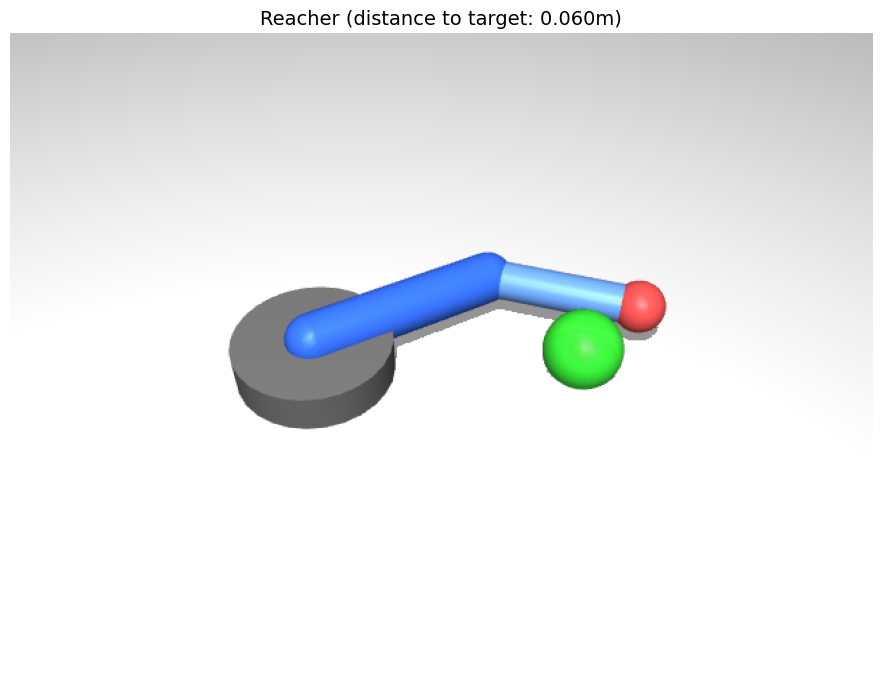

In [16]:
# ============================================================
# 5.3  Visualize the reacher
# ============================================================

show_frame(reacher_model, reacher_data, title=f"Reacher (distance to target: {distance:.3f}m)")

---

## 6. Contact Physics & Advanced Features

Contact handling is where MuJoCo truly shines. Its contact solver uses a convex optimization approach that is:
- **Stable**: No interpenetration or jittering
- **Smooth**: Differentiable contact forces (great for learning)
- **Fast**: Sparse factorization of the constraint Jacobian

### Contact Parameters

| Parameter | Meaning |
|-----------|---------|
| `friction` | `[slide, torsion, roll]` - friction coefficients |
| `solref` | `[timeconst, dampratio]` - constraint solver reference |
| `solimp` | `[dmin, dmax, width]` - solver impedance |
| `contype/conaffinity` | Collision filtering bitmasks |

### Collision Filtering

Two geoms collide only if: `(geom1.contype & geom2.conaffinity) || (geom2.contype & geom1.conaffinity)` is nonzero. This bitwise AND lets you create collision groups efficiently.

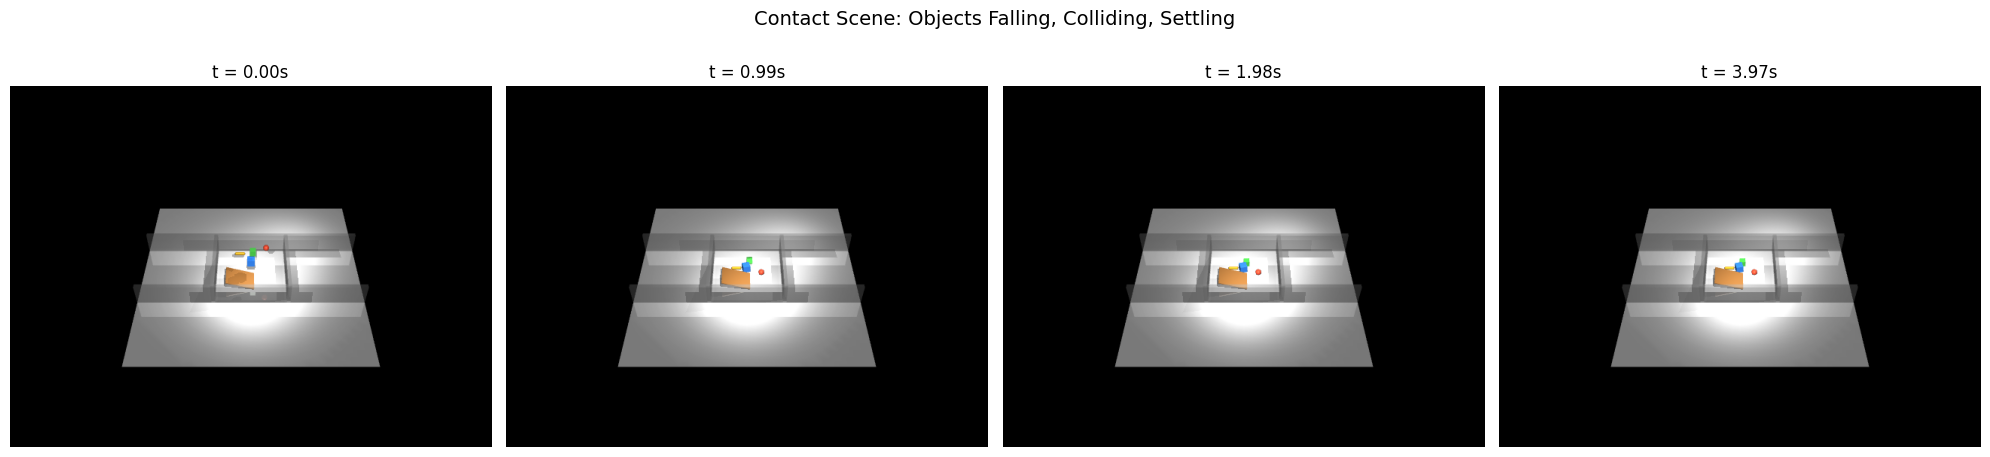

In [17]:
# ============================================================
# 6.1  Contact simulation: objects falling and colliding
# ============================================================

contact_model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "contact_scene.xml"))
contact_data = mujoco.MjData(contact_model)

# Simulate and capture frames
frames = []
dt = contact_model.opt.timestep
renderer = mujoco.Renderer(contact_model, height=480, width=640)
render_every = int(1.0 / (30 * dt))

for step in range(int(4.0 / dt)):
    mujoco.mj_step(contact_model, contact_data)
    if step % render_every == 0:
        renderer.update_scene(contact_data)
        frames.append(renderer.render().copy())

renderer.close()

# Show snapshots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
snapshot_indices = [0, len(frames)//4, len(frames)//2, len(frames)-1]
for i, idx in enumerate(snapshot_indices):
    axes[i].imshow(frames[idx])
    axes[i].set_title(f't = {idx * render_every * dt:.2f}s', fontsize=12)
    axes[i].axis('off')
plt.suptitle('Contact Scene: Objects Falling, Colliding, Settling', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'contact_scene.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# 6.2  Inspecting contacts: what MuJoCo computes
# ============================================================

print(f"Number of active contacts: {contact_data.ncon}")
print()

for i in range(min(contact_data.ncon, 5)):  # Show first 5 contacts
    contact = contact_data.contact[i]
    geom1_name = mujoco.mj_id2name(contact_model, mujoco.mjtObj.mjOBJ_GEOM, contact.geom1) or f"geom_{contact.geom1}"
    geom2_name = mujoco.mj_id2name(contact_model, mujoco.mjtObj.mjOBJ_GEOM, contact.geom2) or f"geom_{contact.geom2}"
    
    print(f"Contact {i}: {geom1_name} <-> {geom2_name}")
    print(f"  Position:     {contact.pos}")
    print(f"  Normal:       {contact.frame[:3]}")
    print(f"  Penetration:  {contact.dist:.6f} m")
    print(f"  Friction:     {contact.friction}")
    print()

print("\nKey insight for RL:")
print("- Contact information can be part of observations (touch sensors)")
print("- Contact forces affect reward (e.g., penalty for excessive force)")
print("- Stable contacts are crucial for manipulation tasks")

Number of active contacts: 11

Contact 0: geom_0 <-> geom_6
  Position:     [-9.67587556e-02  4.11586273e-02 -2.85667019e-05]
  Normal:       [0. 0. 1.]
  Penetration:  -0.000057 m
  Friction:     [0.8   0.8   0.005 0.001 0.001]

Contact 1: geom_0 <-> geom_6
  Position:     [ 9.72551964e-02  8.97239077e-02 -2.85667019e-05]
  Normal:       [0. 0. 1.]
  Penetration:  -0.000057 m
  Friction:     [0.8   0.8   0.005 0.001 0.001]

Contact 2: geom_0 <-> geom_6
  Position:     [-1.45324036e-01  2.35172579e-01 -2.85667019e-05]
  Normal:       [0. 0. 1.]
  Penetration:  -0.000057 m
  Friction:     [0.8   0.8   0.005 0.001 0.001]

Contact 3: geom_0 <-> geom_6
  Position:     [ 4.86899159e-02  2.83737860e-01 -2.85667019e-05]
  Normal:       [0. 0. 1.]
  Penetration:  -0.000057 m
  Friction:     [0.8   0.8   0.005 0.001 0.001]

Contact 4: geom_0 <-> geom_7
  Position:     [-4.63415314e-03  3.06373832e-01 -2.85667019e-05]
  Normal:       [0. 0. 1.]
  Penetration:  -0.000057 m
  Friction:     [0.8   

In [19]:
# ============================================================
# 6.3  The mass matrix and dynamics quantities
# ============================================================
#
# MuJoCo gives you access to fundamental dynamics quantities.
# These are what the physics engine computes internally.

model = mujoco.MjModel.from_xml_path(str(MODELS_DIR / "double_pendulum.xml"))
data = mujoco.MjData(model)
data.qpos[:] = [0.5, -0.3]
mujoco.mj_forward(model, data)

# Get the full mass matrix
M = np.zeros((model.nv, model.nv))
mujoco.mj_fullM(model, M, data.qM)

print("Double Pendulum Dynamics Quantities")
print("=" * 50)
print(f"\nMass matrix M(q) [{model.nv}x{model.nv}]:")
print(f"{M}")
print(f"\nNote: M is symmetric positive definite (always invertible)")
print(f"Eigenvalues: {np.linalg.eigvals(M)}")
print(f"\nBias force c(q, qdot):  {data.qfrc_bias}")
print(f"  (gravity + Coriolis + centrifugal)")
print(f"\nAcceleration qacc:       {data.qacc}")
print(f"\nThe equation of motion: M @ qacc = ctrl_force + bias_force + contact_force")
print(f"\nThis is the equation that MuJoCo solves at every timestep!")

Double Pendulum Dynamics Quantities

Mass matrix M(q) [2x2]:
[[1.7421486  0.6498571 ]
 [0.6498571  0.28682923]]

Note: M is symmetric positive definite (always invertible)
Eigenvalues: [1.99009276 0.03888507]

Bias force c(q, qdot):  [8.69604763 1.48119906]
  (gravity + Coriolis + centrifugal)

Acceleration qacc:       [-19.79343521  39.68112052]

The equation of motion: M @ qacc = ctrl_force + bias_force + contact_force

This is the equation that MuJoCo solves at every timestep!


---

## 7. MuJoCo vs Isaac Sim/Lab

Both are physics simulators used for robot learning, but they target different regimes:

### Architecture Comparison

| Aspect | MuJoCo | Isaac Sim / Isaac Lab |
|--------|--------|----------------------|
| **Engine** | Custom C engine (single-threaded) | PhysX 5 (GPU-accelerated) |
| **Parallelism** | One env per CPU core (or MJX on GPU) | Thousands of envs on one GPU |
| **Speed** | ~1M steps/s (simple), ~100K (complex) | ~100K envs x 1000 steps/s on GPU |
| **Contact solver** | Convex optimization (smooth, accurate) | PGS / TGS (fast, less smooth) |
| **Rendering** | Basic OpenGL, offscreen | RTX ray-tracing, photorealistic |
| **Model format** | MJCF (XML) or URDF | USD, URDF |
| **Differentiable** | Yes (MJX via JAX) | Partially (through Warp) |
| **Platform** | macOS, Linux, Windows | Linux (primarily), Windows |
| **License** | Apache 2.0 (free) | Free for research (NVIDIA) |

### When to Use Which?

| Use Case | Best Choice | Why |
|----------|------------|-----|
| **RL research / benchmarking** | MuJoCo | Standard benchmarks, reproducibility |
| **Massively parallel training** | Isaac Lab | GPU parallelism, 10-100x faster wall-clock |
| **Sim-to-real transfer** | Isaac Lab | Domain randomization at scale, photorealism |
| **Contact-rich manipulation** | MuJoCo | Superior contact solver, smoother gradients |
| **Quick prototyping** | MuJoCo | Simpler API, easier setup |
| **Large-scale locomotion** | Isaac Lab | Massively parallel env training |
| **Differentiable physics** | MuJoCo MJX | Native JAX support, analytical gradients |

### Key Philosophical Differences

1. **MuJoCo thinks in generalized coordinates** (joint angles): The state is `(qpos, qvel)` in joint space. This is compact and efficient for articulated robots.

2. **Isaac Sim thinks in Cartesian space**: Bodies have world-frame poses. More intuitive but requires constraint solvers for joints.

3. **MuJoCo's contact model is optimization-based**: Solves a convex program for contact forces. This gives smoother force profiles (better for gradient-based learning).

4. **Isaac's contact model is iterative (PGS/TGS)**: Faster per iteration but can produce noisy force profiles. Compensated by massive parallelism.

5. **Isaac Lab wraps Isaac Sim for RL**: Provides vectorized env API, automatic domain randomization, and curriculum learning. Similar to what Gymnasium does for MuJoCo but at GPU scale.

### The Convergence

Both ecosystems are converging:
- **MuJoCo MJX** adds GPU parallelism via JAX
- **Isaac Lab** improves contact physics and adds analytical gradients
- Both support URDF import for robot models
- Both integrate with standard RL libraries (SB3, RSL-RL, rl_games)

In [20]:
# ============================================================
# 7.1  MuJoCo performance benchmark
# ============================================================
#
# Let's measure how fast MuJoCo actually is.

import time

benchmarks = {
    "simple_pendulum": MODELS_DIR / "simple_pendulum.xml",
    "cart_pole": MODELS_DIR / "cart_pole.xml",
    "double_pendulum": MODELS_DIR / "double_pendulum.xml",
    "reacher": MODELS_DIR / "reacher.xml",
    "contact_scene": MODELS_DIR / "contact_scene.xml",
}

n_steps = 100_000

print(f"Benchmark: {n_steps:,} simulation steps")
print("=" * 55)

for name, path in benchmarks.items():
    m = mujoco.MjModel.from_xml_path(str(path))
    d = mujoco.MjData(m)
    
    # Warm up
    for _ in range(1000):
        mujoco.mj_step(m, d)
    
    mujoco.mj_resetData(m, d)
    
    start = time.perf_counter()
    for _ in range(n_steps):
        mujoco.mj_step(m, d)
    elapsed = time.perf_counter() - start
    
    steps_per_sec = n_steps / elapsed
    sim_time = n_steps * m.opt.timestep
    realtime_factor = sim_time / elapsed
    
    print(f"  {name:20s} | {steps_per_sec:>10,.0f} steps/s | {realtime_factor:>6.0f}x realtime | nq={m.nq}, nv={m.nv}")

print("\nFor comparison, Isaac Lab can run ~100K parallel envs on a single GPU.")
print("But MuJoCo's single-thread speed is remarkable for its accuracy.")
print("MuJoCo MJX (JAX backend) bridges this gap with GPU batching.")

Benchmark: 100,000 simulation steps
  simple_pendulum      |    791,612 steps/s |   1583x realtime | nq=1, nv=1
  cart_pole            |    752,302 steps/s |   1505x realtime | nq=2, nv=2
  double_pendulum      |    756,006 steps/s |    756x realtime | nq=2, nv=2
  reacher              |     70,919 steps/s |    142x realtime | nq=2, nv=2
  contact_scene        |    103,558 steps/s |    207x realtime | nq=28, nv=24

For comparison, Isaac Lab can run ~100K parallel envs on a single GPU.
But MuJoCo's single-thread speed is remarkable for its accuracy.
MuJoCo MJX (JAX backend) bridges this gap with GPU batching.


---

## 8. Gymnasium Integration

**Gymnasium** (successor to OpenAI Gym) is the standard API for RL environments. It wraps MuJoCo simulations into a clean `step(action) -> (obs, reward, terminated, truncated, info)` interface.

### The Gymnasium API

```python
env = gymnasium.make("InvertedPendulum-v5")
obs, info = env.reset()

for _ in range(1000):
    action = env.action_space.sample()  # random action
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()
```

### Standard MuJoCo Environments

| Environment | DOF | Description | Difficulty |
|------------|-----|-------------|------------|
| InvertedPendulum | 1 | Balance a pole on a cart | Easy |
| Reacher | 2 | 2D arm reaches target | Easy |
| HalfCheetah | 6 | 2D running cheetah | Medium |
| Hopper | 3 | 2D hopping robot | Medium |
| Walker2d | 6 | 2D bipedal walking | Hard |
| Ant | 8 | 3D quadruped locomotion | Hard |
| Humanoid | 17 | 3D humanoid locomotion | Very Hard |

InvertedPendulum-v5 Environment
Observation space: Box(-inf, inf, (4,), float64)
  Shape: (4,)
  Low:   [-inf -inf -inf -inf]
  High:  [inf inf inf inf]

Action space: Box(-3.0, 3.0, (1,), float32)
  Shape: (1,)
  Low:   [-3.]
  High:  [3.]

Initial observation: [ 0.00547912 -0.00122243  0.00717196  0.00394736]
  [0] cart position:     0.0055
  [1] cart velocity:     -0.0012
  [2] pole angle:        0.0072
  [3] pole angular vel:  0.0039


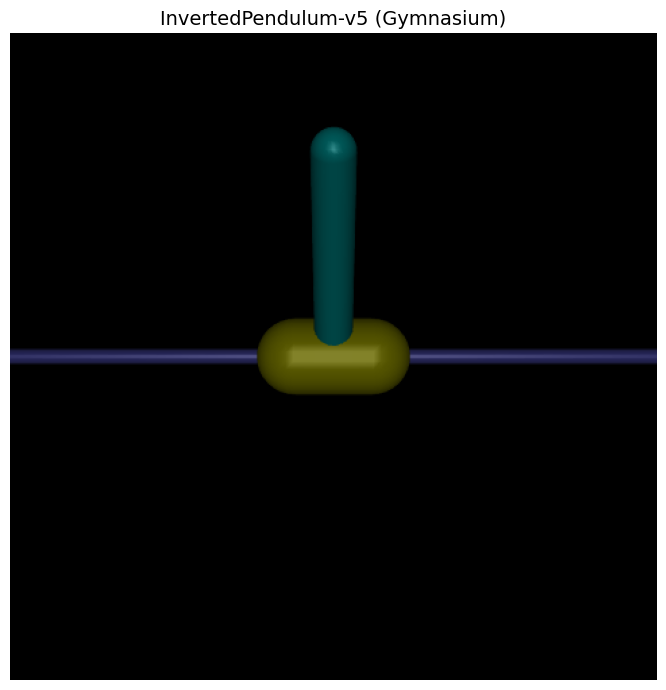

In [21]:
# ============================================================
# 8.1  Exploring a Gymnasium MuJoCo environment
# ============================================================

import gymnasium as gym

# Create the InvertedPendulum environment
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")

print("InvertedPendulum-v5 Environment")
print("=" * 50)
print(f"Observation space: {env.observation_space}")
print(f"  Shape: {env.observation_space.shape}")
print(f"  Low:   {env.observation_space.low}")
print(f"  High:  {env.observation_space.high}")
print()
print(f"Action space: {env.action_space}")
print(f"  Shape: {env.action_space.shape}")
print(f"  Low:   {env.action_space.low}")
print(f"  High:  {env.action_space.high}")
print()

# Reset and inspect
obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}")
print(f"  [0] cart position:     {obs[0]:.4f}")
print(f"  [1] cart velocity:     {obs[1]:.4f}")
print(f"  [2] pole angle:        {obs[2]:.4f}")
print(f"  [3] pole angular vel:  {obs[3]:.4f}")

# Render
frame = env.render()
plt.figure(figsize=(10, 7))
plt.imshow(frame)
plt.title('InvertedPendulum-v5 (Gymnasium)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 8.2  Understanding the reward structure
# ============================================================

obs, info = env.reset(seed=42)
total_reward = 0
steps = 0

# Run with random actions to see how reward works
rewards_random = []
for _ in range(1000):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    rewards_random.append(reward)
    steps += 1
    if terminated or truncated:
        break

print(f"Random policy: survived {steps} steps, total reward = {total_reward:.1f}")
print(f"Reward per step: {reward:.1f} (1.0 while pole is upright, episode ends when it falls)")
print(f"\nThe reward structure is simple:")
print(f"  - +1 for every step the pole stays upright")
print(f"  - Episode terminates when pole angle > ~0.2 rad")
print(f"  - Maximum episode length: 1000 steps")
print(f"  - Perfect score: 1000")

Random policy: survived 14 steps, total reward = 13.0
Reward per step: 0.0 (1.0 while pole is upright, episode ends when it falls)

The reward structure is simple:
  - +1 for every step the pole stays upright
  - Episode terminates when pole angle > ~0.2 rad
  - Maximum episode length: 1000 steps
  - Perfect score: 1000


In [23]:
# ============================================================
# 8.3  Accessing MuJoCo internals through Gymnasium
# ============================================================
#
# Gymnasium wraps MuJoCo but you can still access the raw model/data!

obs, info = env.reset(seed=42)

# Access the underlying MuJoCo model and data
mj_model = env.unwrapped.model
mj_data = env.unwrapped.data

print("Accessing MuJoCo internals through Gymnasium:")
print(f"  model.nq:     {mj_model.nq}")
print(f"  model.nv:     {mj_model.nv}")
print(f"  model.nu:     {mj_model.nu}")
print(f"  data.qpos:    {mj_data.qpos}")
print(f"  data.qvel:    {mj_data.qvel}")
print(f"  model.opt.dt: {mj_model.opt.timestep}")
print()

# How many MuJoCo steps per env.step()?
# Gymnasium uses "frame_skip" - multiple MuJoCo steps per RL step
frame_skip = env.unwrapped.frame_skip if hasattr(env.unwrapped, 'frame_skip') else 'N/A'
print(f"  frame_skip:   {frame_skip}")
print(f"  RL timestep:  {mj_model.opt.timestep * (frame_skip if isinstance(frame_skip, int) else 1):.4f}s")
print(f"\nThis means each env.step() runs {frame_skip} MuJoCo steps internally.")
print(f"The RL agent operates at a LOWER frequency than the physics simulation.")
print(f"This is realistic: real robots also have control frequencies << physics frequencies.")

env.close()

Accessing MuJoCo internals through Gymnasium:
  model.nq:     2
  model.nv:     2
  model.nu:     1
  data.qpos:    [ 0.00547912 -0.00122243]
  data.qvel:    [0.00717196 0.00394736]
  model.opt.dt: 0.02

  frame_skip:   2
  RL timestep:  0.0400s

This means each env.step() runs 2 MuJoCo steps internally.
The RL agent operates at a LOWER frequency than the physics simulation.
This is realistic: real robots also have control frequencies << physics frequencies.


---

## 9. Your First RL Agent

Let's train a real RL agent! We'll use **PPO** (Proximal Policy Optimization) from **Stable-Baselines3** on the InvertedPendulum task.

### Why PPO?
- Most widely used on-policy algorithm
- Robust, works well out-of-the-box
- Good baseline before trying SAC, TD3, etc.

### The RL Loop

```
Policy Network (MLP)
       |
       v
   action (torque on cart)
       |
       v
MuJoCo Simulation (via Gymnasium)
       |
       v
   observation (cart pos, vel, pole angle, angular vel)
   reward (+1 per step alive)
       |
       v
PPO Update (policy gradient with clipping)
```

In [24]:
# ============================================================
# 9.1  Train PPO on InvertedPendulum
# ============================================================

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv

# Create the environment
env = gym.make("InvertedPendulum-v5")

# Create PPO agent
# - MlpPolicy: 2-layer MLP with 64 units each (default)
# - learning_rate: step size for policy updates
# - n_steps: number of steps to collect before each update
ppo_agent = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,          # discount factor
    gae_lambda=0.95,     # GAE parameter
    clip_range=0.2,      # PPO clipping parameter
    verbose=1,
    seed=42,
)

print("PPO Agent Architecture:")
print(ppo_agent.policy)
print(f"\nTotal parameters: {sum(p.numel() for p in ppo_agent.policy.parameters()):,}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
PPO Agent Architecture:
ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=1, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

Total parameter

In [25]:
# ============================================================
# 9.2  Evaluate BEFORE training (random baseline)
# ============================================================

eval_env = gym.make("InvertedPendulum-v5")

# Evaluate untrained agent
mean_reward_before, std_reward_before = evaluate_policy(
    ppo_agent, eval_env, n_eval_episodes=20, deterministic=True
)
print(f"Before training: mean reward = {mean_reward_before:.1f} +/- {std_reward_before:.1f}")
print(f"(Random policy typically survives ~50-100 steps out of 1000)")

Before training: mean reward = 24.1 +/- 5.1
(Random policy typically survives ~50-100 steps out of 1000)


/Users/dpaul/Documents/Dream Machines/05 Research papers/ClaudeRL/code/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


In [26]:
# ============================================================
# 9.3  Train!
# ============================================================
#
# InvertedPendulum is simple enough that PPO solves it quickly.
# More complex environments (HalfCheetah, Ant) need 1M+ steps.

print("Training PPO on InvertedPendulum-v5...")
print("This should take ~30-60 seconds for 50K steps.\n")

ppo_agent.learn(
    total_timesteps=50_000,
    progress_bar=True,
)

print("\nTraining complete!")

Output()

Training PPO on InvertedPendulum-v5...
This should take ~30-60 seconds for 50K steps.

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.7      |
|    ep_rew_mean     | 6.7      |
| time/              |          |
|    fps             | 6093     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10          |
|    ep_rew_mean          | 9.01        |
| time/                   |             |
|    fps                  | 4365        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.015636146 |
|    clip_fraction        | 0.133       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.4        |
|    explained_variance   | -0.000234   |
|    learning_rate        | 0.0003      |
|    loss                 | 6.86        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0179     |
|    std                  | 0.974       |
|    value_loss           | 16.8        |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12.2        |
|    ep_rew_mean          | 11.2        |
| time/                   |             |
|    fps                  | 4040        |
|    iterations           | 3           |
|    time_elapsed         | 0           |
|    total_timesteps      | 3072        |
| train/                  |             |
|    approx_kl            | 0.018727483 |
|    clip_fraction        | 0.188       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.37       |
|    explained_variance   | 0.0381      |
|    learning_rate        | 0.0003      |
|    loss                 | 8.43        |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0257     |
|    std                  | 0.939       |
|    value_loss           | 13.7        |
-----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 16.2       |
|    ep_rew_mean          | 15.2       |
| time/                   |            |
|    fps                  | 3886       |
|    iterations           | 4          |
|    time_elapsed         | 1          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.02256792 |
|    clip_fraction        | 0.174      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.34      |
|    explained_variance   | 0.11       |
|    learning_rate        | 0.0003     |
|    loss                 | 6.76       |
|    n_updates            | 30         |
|    policy_gradient_loss | -0.0289    |
|    std                  | 0.911      |
|    value_loss           | 19.7       |
----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 389         |
|    ep_rew_mean          | 389         |
| time/                   |             |
|    fps                  | 3526        |
|    iterations           | 46          |
|    time_elapsed         | 13          |
|    total_timesteps      | 47104       |
| train/                  |             |
|    approx_kl            | 0.008479139 |
|    clip_fraction        | 0.08        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.32       |
|    explained_variance   | -0.0106     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0138     |
|    n_updates            | 450         |
|    policy_gradient_loss | -0.00386    |
|    std                  | 0.908       |
|    value_loss           | 0.000433    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 398         |
|    ep_rew_mean          | 398         |
| time/                   |             |
|    fps                  | 3518        |
|    iterations           | 47          |
|    time_elapsed         | 13          |
|    total_timesteps      | 48128       |
| train/                  |             |
|    approx_kl            | 0.008712735 |
|    clip_fraction        | 0.112       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.32       |
|    explained_variance   | -0.0528     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0344     |
|    n_updates            | 460         |
|    policy_gradient_loss | -0.0048     |
|    std                  | 0.908       |
|    value_loss           | 0.000271    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 408          |
|    ep_rew_mean          | 407          |
| time/                   |              |
|    fps                  | 3512         |
|    iterations           | 48           |
|    time_elapsed         | 13           |
|    total_timesteps      | 49152        |
| train/                  |              |
|    approx_kl            | 0.0042677023 |
|    clip_fraction        | 0.0732       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.32        |
|    explained_variance   | -0.115       |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0112      |
|    n_updates            | 470          |
|    policy_gradient_loss | -0.00257     |
|    std                  | 0.912        |
|    value_loss           | 0.00021      |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 417         |
|    ep_rew_mean          | 416         |
| time/                   |             |
|    fps                  | 3508        |
|    iterations           | 49          |
|    time_elapsed         | 14          |
|    total_timesteps      | 50176       |
| train/                  |             |
|    approx_kl            | 0.004895054 |
|    clip_fraction        | 0.0237      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.34       |
|    explained_variance   | -0.348      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00975     |
|    n_updates            | 480         |
|    policy_gradient_loss | 2.47e-05    |
|    std                  | 0.929       |
|    value_loss           | 0.000143    |
-----------------------------------------



Training complete!


In [27]:
# ============================================================
# 9.4  Evaluate AFTER training
# ============================================================

mean_reward_after, std_reward_after = evaluate_policy(
    ppo_agent, eval_env, n_eval_episodes=20, deterministic=True
)
print(f"After training:  mean reward = {mean_reward_after:.1f} +/- {std_reward_after:.1f}")
print(f"Before training: mean reward = {mean_reward_before:.1f} +/- {std_reward_before:.1f}")
print(f"\nImprovement: {mean_reward_after - mean_reward_before:.1f} reward points")
if mean_reward_after > 900:
    print("The agent has essentially SOLVED the task (max=1000)!")
elif mean_reward_after > 500:
    print("Good progress! More training steps would improve this further.")
else:
    print("Still learning. Try more training steps (100K+).")

After training:  mean reward = 1000.0 +/- 0.0
Before training: mean reward = 24.1 +/- 5.1

Improvement: 976.0 reward points
The agent has essentially SOLVED the task (max=1000)!


In [28]:
# ============================================================
# 9.5  Visualize the trained agent
# ============================================================

vis_env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")
obs, info = vis_env.reset(seed=42)

frames = []
observations = []
actions_taken = []
rewards_collected = []

for step in range(500):  # Run for 500 steps
    # Get action from trained policy
    action, _states = ppo_agent.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = vis_env.step(action)
    
    observations.append(obs.copy())
    actions_taken.append(action.copy())
    rewards_collected.append(reward)
    
    # Render every 5th frame
    if step % 5 == 0:
        frames.append(vis_env.render())
    
    if terminated or truncated:
        print(f"Episode ended at step {step}")
        break

vis_env.close()

# Show video or snapshots
if HAS_MEDIAPY and len(frames) > 0:
    media.show_video(frames, fps=20, title="Trained PPO Agent")
else:
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    for i, idx in enumerate(np.linspace(0, len(frames)-1, 5, dtype=int)):
        axes[i].imshow(frames[idx])
        axes[i].set_title(f'Step {idx * 5}', fontsize=12)
        axes[i].axis('off')
    plt.suptitle('Trained PPO Agent on InvertedPendulum', fontsize=14)
    plt.tight_layout()
    plt.show()

print(f"\nTotal reward: {sum(rewards_collected):.0f} / {len(rewards_collected)}")


Total reward: 500 / 500


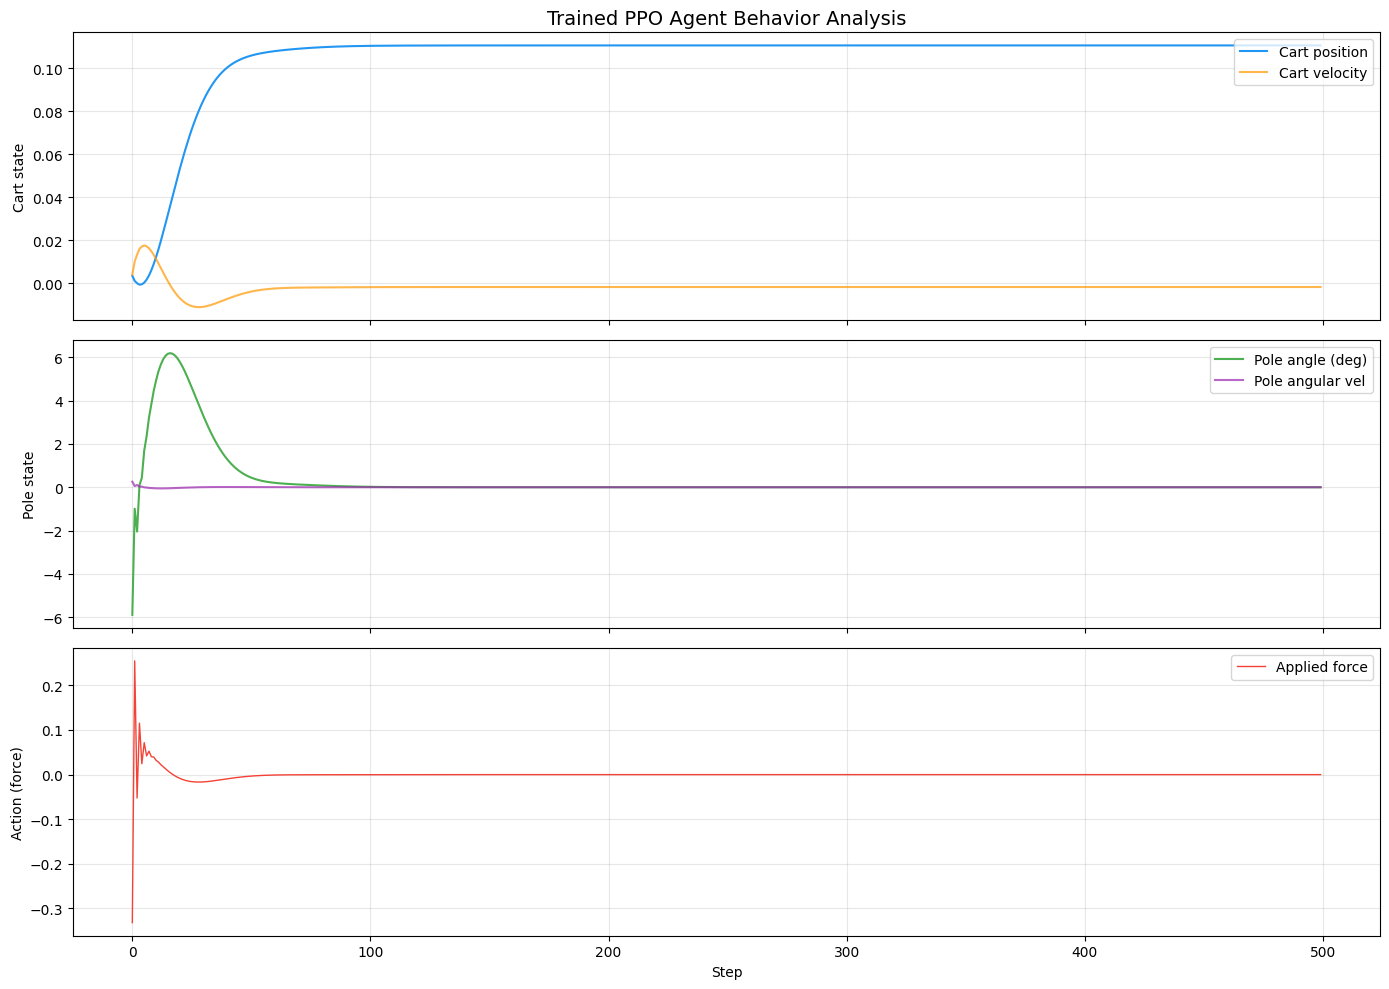


Observations:
  - Pole angle stays very close to 0 (upright) - the agent learned to balance!
  - Actions are small corrective forces (not wild swings)
  - Max pole deviation: 6.20 degrees
  - Mean absolute action: 0.0031 (efficient control)


In [29]:
# ============================================================
# 9.6  Analyze the learned behavior
# ============================================================

observations = np.array(observations)
actions_taken = np.array(actions_taken)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

steps_range = np.arange(len(observations))

# Cart position and velocity
axes[0].plot(steps_range, observations[:, 0], label='Cart position', color='#2196F3', linewidth=1.5)
axes[0].plot(steps_range, observations[:, 1], label='Cart velocity', color='#FF9800', linewidth=1.5, alpha=0.7)
axes[0].set_ylabel('Cart state')
axes[0].legend(loc='upper right')
axes[0].set_title('Trained PPO Agent Behavior Analysis', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Pole angle and velocity
axes[1].plot(steps_range, np.degrees(observations[:, 2]), label='Pole angle (deg)', color='#4CAF50', linewidth=1.5)
axes[1].plot(steps_range, observations[:, 3], label='Pole angular vel', color='#9C27B0', linewidth=1.5, alpha=0.7)
axes[1].set_ylabel('Pole state')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Actions
axes[2].plot(steps_range, actions_taken[:, 0], label='Applied force', color='#F44336', linewidth=1)
axes[2].set_ylabel('Action (force)')
axes[2].set_xlabel('Step')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ppo_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations:")
print(f"  - Pole angle stays very close to 0 (upright) - the agent learned to balance!")
print(f"  - Actions are small corrective forces (not wild swings)")
print(f"  - Max pole deviation: {np.max(np.abs(np.degrees(observations[:, 2]))):.2f} degrees")
print(f"  - Mean absolute action: {np.mean(np.abs(actions_taken)):.4f} (efficient control)")

In [30]:
# ============================================================
# 9.7  Save the trained model for later use
# ============================================================

save_path = SAVED_MODELS_DIR / "ppo_inverted_pendulum"
ppo_agent.save(save_path)
print(f"Model saved to: {save_path}")
print(f"\nTo load later:")
print(f"  loaded_agent = PPO.load('{save_path}')")
print(f"  action, _ = loaded_agent.predict(obs)")

# Clean up
env.close()
eval_env.close()

Model saved to: /Users/dpaul/Documents/Dream Machines/05 Research papers/ClaudeRL/code/mujoco_tutorial/saved_models/ppo_inverted_pendulum

To load later:
  loaded_agent = PPO.load('/Users/dpaul/Documents/Dream Machines/05 Research papers/ClaudeRL/code/mujoco_tutorial/saved_models/ppo_inverted_pendulum')
  action, _ = loaded_agent.predict(obs)


---

## Summary & What's Next

### What We Covered

1. **MuJoCo fundamentals**: `mjModel` (static) vs `mjData` (dynamic), nq vs nv
2. **MJCF modeling**: Building robots in XML, kinematic trees, bodies/joints/geoms
3. **Simulation loop**: `mj_step()`, forward dynamics, energy conservation
4. **Control**: Motor vs position actuators, swing-up control
5. **Sensors**: Building observation vectors, cos/sin representation
6. **Contact physics**: Collision detection, contact forces, mass matrix
7. **MuJoCo vs Isaac**: When to use each, architectural differences
8. **Gymnasium**: Standard RL API wrapping MuJoCo
9. **RL Agent**: Trained PPO to balance InvertedPendulum

### Key Takeaways for RL Implementation

- **State = (qpos, qvel)**: Joint positions and velocities are the natural state
- **Action = ctrl**: Control signal to actuators (torques, positions, or velocities)
- **Reward design matters**: Simple rewards (+1/step) work for simple tasks; complex tasks need shaped rewards
- **Frame skip**: RL operates at lower frequency than physics (typically 2-5 MuJoCo steps per RL step)
- **Observation design**: Use cos/sin for angles, normalize values, include velocities

### Next Steps for Your RL Methods

1. **Try harder environments**: HalfCheetah-v5, Ant-v5, Humanoid-v5
2. **Compare algorithms**: SAC vs PPO vs TD3 on the same environment
3. **Implement from scratch**: Build your own SAC/PPO using the MuJoCo API directly
4. **Custom environments**: Design your own MJCF model + Gymnasium wrapper
5. **Domain randomization**: Vary physics parameters during training for robustness
6. **Sim-to-real considerations**: What works in MuJoCo vs real hardware

### Useful Resources

- [MuJoCo Documentation](https://mujoco.readthedocs.io/)
- [MuJoCo Python API](https://mujoco.readthedocs.io/en/stable/python.html)
- [MJCF Reference](https://mujoco.readthedocs.io/en/stable/XMLreference.html)
- [Gymnasium MuJoCo Envs](https://gymnasium.farama.org/environments/mujoco/)
- [Stable-Baselines3](https://stable-baselines3.readthedocs.io/)
- [MuJoCo MJX (JAX)](https://mujoco.readthedocs.io/en/stable/mjx.html)